# Volcano Map Axes

### IMPORT ARGUMENTS

In [1]:
import pandas as pd
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.transforms import offset_copy

import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

import cartopy.feature as cfeature

import utils

### LOAD DATA

In [2]:
# VOLCANO
volc = dict({'lat':-8.343, 'lon':115.508, 'elev':2997})
volc2= dict({'lat':-8.242, 'lon':115.375, 'elev':1717}) # Batur

# volc = [
#     dict({'lat':-8.343, 'lon':115.508, 'elev':2997}), # Agung
#     dict({'lat':-8.242, 'lon':115.375, 'elev':1717}) # Batur
# ]
# volc = pd.DataFrame(volc)
print(volc)

# CATALOG
eqcat = pd.read_csv('./data/agung_catalog.txt', parse_dates=[3], index_col=[3]).tz_localize('UTC')#.tz_convert('Asia/Singapore')

# SEISMOMETERS
stations = [
    dict({'name':'TMKS', 'lon':115.46675, 'lat':-8.36383, 'used':True}),
    dict({'name':'PSAG', 'lon':115.49872, 'lat':-8.37769, 'used':True}),
    dict({'name':'ABNG', 'lon':115.43476667, 'lat':-8.29436667, 'used':True}),
    dict({'name':'YHKR', 'lon':115.50838252, 'lat':-8.38157119, 'used':True}),
    dict({'name':'CEGI', 'lon':115.4716111, 'lat':-8.30494, 'used':True}),

    dict({'name':'BTR', 'lon':115.37636, 'lat':-8.24523, 'used':False}),
    dict({'name':'REND', 'lon':115.43167611, 'lat':-8.42471940, 'used':False}),
    dict({'name':'DUKU', 'lon':115.5341944, 'lat':-8.29586, 'used':False}),
    dict({'name':'BATU', 'lon':115.49954, 'lat':-8.20885, 'used':False}),
    dict({'name':'DNU', 'lon':115.38533, 'lat':-8.26944, 'used':False}),
    dict({'name':'DNU', 'lon':115.38853, 'lat':-8.23, 'used':False}),
]
stations = pd.DataFrame(stations)
print(stations)

{'lat': -8.343, 'lon': 115.508, 'elev': 2997}
    name         lon       lat   used
0   TMKS  115.466750 -8.363830   True
1   PSAG  115.498720 -8.377690   True
2   ABNG  115.434767 -8.294367   True
3   YHKR  115.508383 -8.381571   True
4   CEGI  115.471611 -8.304940   True
5    BTR  115.376360 -8.245230  False
6   REND  115.431676 -8.424719  False
7   DUKU  115.534194 -8.295860  False
8   BATU  115.499540 -8.208850  False
9    DNU  115.385330 -8.269440  False
10   DNU  115.388530 -8.230000  False


### USER SETTINGS

In [3]:
filepath = './test_eqmap'
grid_size = 0.01 # grid_size for eq heatmap in degrees
map_style = 'terrain-background'
zoom_level = 12
radial_map_extent = 20 # km
radius_km = 10 # km
transform = ccrs.PlateCarree()

### CREATE MAP

Saving .png


/Users/jwellik/opt/anaconda3/envs/seismology38/lib/python3.8/site-packages/cartopy/crs.py:825: ShapelyDeprecationWarning: __len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
  if len(multi_line_string) > 1:
/Users/jwellik/opt/anaconda3/envs/seismology38/lib/python3.8/site-packages/cartopy/crs.py:877: ShapelyDeprecationWarning: Iteration over multi-part geometries is deprecated and will be removed in Shapely 2.0. Use the `geoms` property to access the constituent parts of a multi-part geometry.
  for line in multi_line_string:
/Users/jwellik/opt/anaconda3/envs/seismology38/lib/python3.8/site-packages/cartopy/crs.py:944: ShapelyDeprecationWarning: __len__ for multi-part geometries is deprecated and will be removed in Shapely 2.0. Check the length of the `geoms` property instead to get the  number of parts of a multi-part geometry.
  if len(p_mline) > 0:


Saving .svg


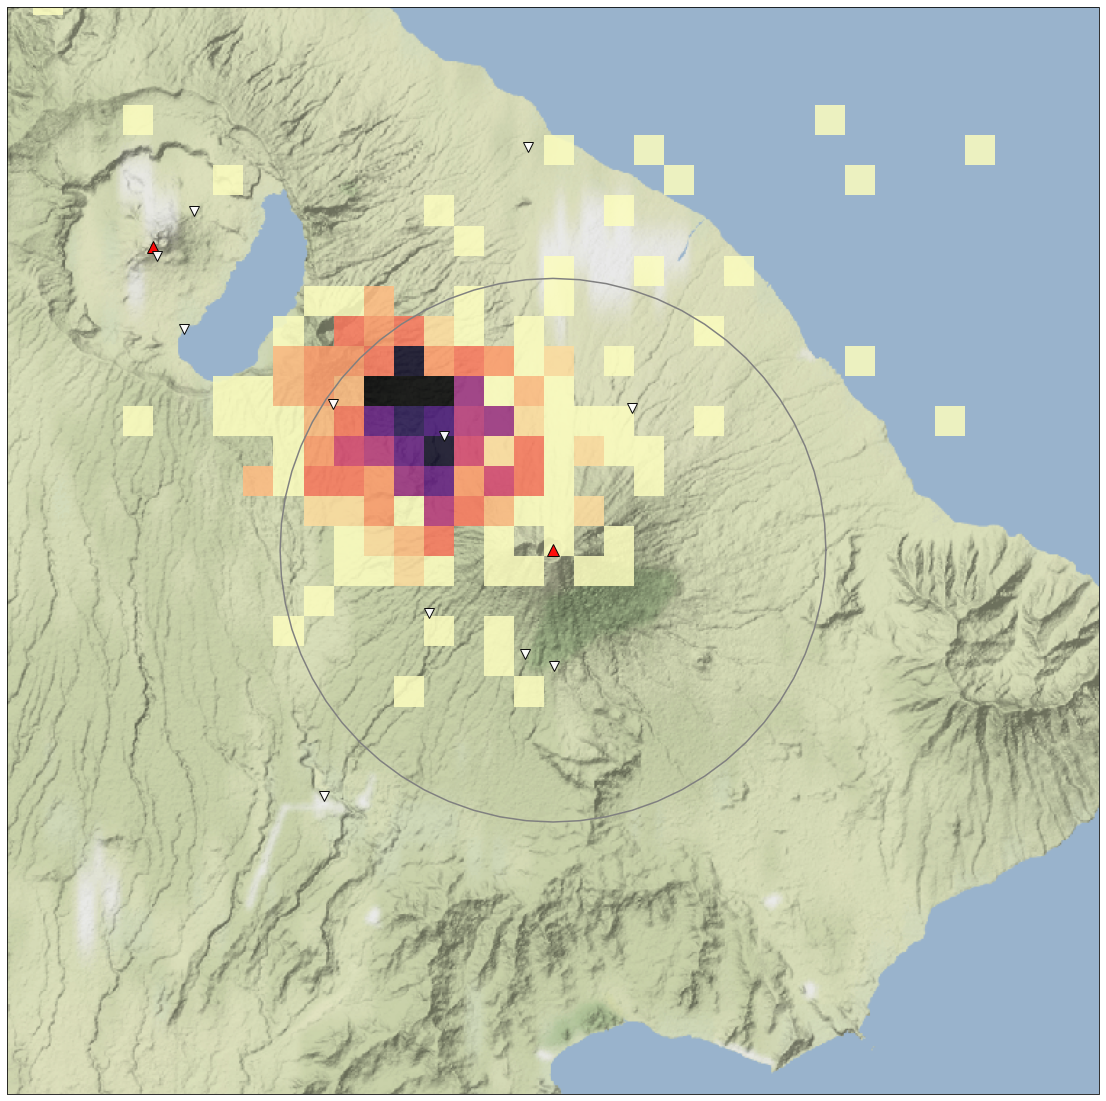

In [6]:
plt.style.use('./utils/eqmap.mplstyle')
fig = plt.figure(figsize=[20,20]) # default figsize is [12x12]
axm = fig.add_subplot(1, 1, 1, projection=transform)
axm = utils.set_radial_map_extent(axm, volc['lat'], volc['lon'], radial_map_extent, crs=transform) # Limit the extent of the map to a small longitude/latitude range.

axm = utils.stamen_background(axm, map_style, zoom_level) # add background image
axm = utils.plot_heatmap(axm, eqcat, grid_size, colormap='magma_r') # plot EQ heatmap
axm = utils.plot_volcano(axm, volc['lat'], volc['lon'], transform=ccrs.Geodesic()) # add marker for volcano
axm = utils.plot_volcano(axm, volc2['lat'], volc2['lon'], transform=ccrs.Geodesic()) # add marker for volcano
axm = utils.plot_radius(axm, volc['lat'], volc['lon'], radius_km, transform=transform)
axm = utils.plot_station(axm, stations['lat'], stations['lon'], color='white', transform=ccrs.Geodesic()) # add marker for volcano
#fig = utils.location_map(fig, volc['lat'], volc['lon'], location='top_left')

utils.save(fig, filepath)
plt.show()